In [19]:
# Importamos las librerías necesarias
import numpy as np                # Para cálculos numéricos y aleatorios
import matplotlib.pyplot as plt   # Para graficar los resultados

# Tamaño del tablero (5x5)
GRID_SIZE = 5

# Acciones posibles: arriba, abajo, izquierda, derecha
ACTIONS = ["up", "down", "left", "right"]


In [20]:
# Inicializa posiciones aleatorias de la cabeza y la comida
def init_positions():
    head = np.random.randint(0, GRID_SIZE, size=2)  # posición de la serpiente
    food = np.random.randint(0, GRID_SIZE, size=2)  # posición de la comida
    # Nos aseguramos de que no empiecen en la misma celda
    while np.array_equal(head, food):
        food = np.random.randint(0, GRID_SIZE, size=2)
    return head, food


In [21]:
# Define el movimiento de la cabeza según la acción
def move(head, action):
    if action == "up":
        head = head + np.array([-1, 0])
    elif action == "down":
        head = head + np.array([1, 0])
    elif action == "left":
        head = head + np.array([0, -1])
    elif action == "right":
        head = head + np.array([0, 1])
    return head

In [22]:
# Calcula la recompensa según el resultado del movimiento
def get_reward(head, food):
    if np.array_equal(head, food):
        return 1   # +1 si come
    elif np.any(head < 0) or np.any(head >= GRID_SIZE):
        return -1  # -1 si choca con los bordes
    else:
        return 0   # 0 si simplemente se mueve



In [23]:
# Representa el estado (posición relativa comida - serpiente)
def get_state(head, food):
    dx = np.sign(food[0] - head[0])  # dirección vertical: -1 arriba, 0 igual, 1 abajo
    dy = np.sign(food[1] - head[1])  # dirección horizontal: -1 izquierda, 0 igual, 1 derecha
    return (dx, dy)  # estado como tupla

In [24]:
# --- PARÁMETROS DE APRENDIZAJE ---
epsilons = [0, 0.05, 0.1]   # Grados de exploración
episodios = 2000             # Número de partidas
recompensas_medias = np.zeros((len(epsilons), episodios))  # Para almacenar recompensas

# --- ENTRENAMIENTO ---
for i, eps in enumerate(epsilons):

    # Diccionarios para valores Q y conteos N
    Q = {}   # Q[state][action] = valor estimado
    N = {}   # N[state][action] = veces seleccionada

    # --- Contadores globales ---
    comidas = 0      # Veces que comió la manzana
    choques = 0      # Veces que chocó con el borde

    # --- Episodios ---
    for ep in range(episodios):
        head, food = init_positions()   # Posiciones iniciales
        total_reward = 0                # Recompensa acumulada por episodio

        # --- Movimiento dentro de un episodio ---
        for _ in range(50):  # Máximo 50 pasos por partida
            state = get_state(head, food)

            # Si el estado no existe en la tabla Q, lo inicializamos
            if state not in Q:
                Q[state] = {a: 0.0 for a in ACTIONS}
                N[state] = {a: 0 for a in ACTIONS}

            # --- Política ε-greedy ---
            if np.random.rand() < eps:
                action = np.random.choice(ACTIONS)  # Explora (aleatorio)
            else:
                action = max(Q[state], key=Q[state].get)  # Explota (mejor acción conocida)

            # --- Ejecutar acción ---
            new_head = move(head.copy(), action)
            reward = get_reward(new_head, food)
            total_reward += reward

            # --- Contadores de eventos ---
            if reward == 1:
                comidas += 1
            elif reward == -1:
                choques += 1

            # --- Actualización incremental de Q(s,a) ---
            N[state][action] += 1
            Q[state][action] += (reward - Q[state][action]) / N[state][action]

            # Actualizar la cabeza
            head = new_head

            # Si come o choca, termina el episodio
            if reward != 0:
                break

        # Guarda la recompensa total de este episodio
        recompensas_medias[i, ep] = total_reward

    # --- Resultados finales por cada valor de ε ---
    print(f"ε = {eps:.2f} → 🍎 Comidas: {comidas} | 💥 Choques: {choques}")


ε = 0.00 → 🍎 Comidas: 1987 | 💥 Choques: 8
ε = 0.05 → 🍎 Comidas: 1943 | 💥 Choques: 57
ε = 0.10 → 🍎 Comidas: 1892 | 💥 Choques: 103


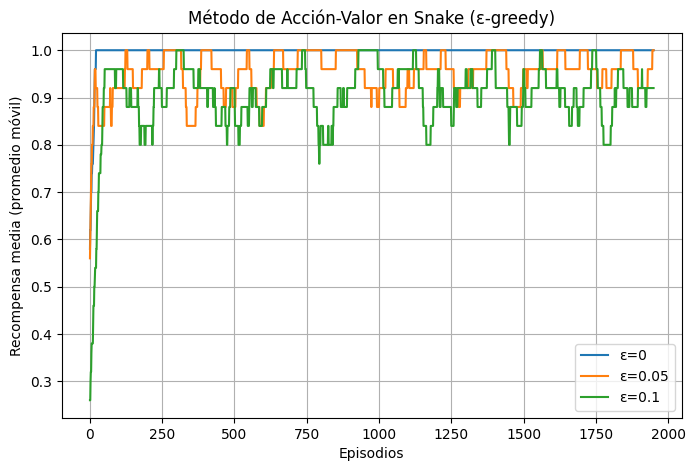

In [25]:
# --- GRÁFICO 1: Recompensa media (promedio móvil) ---
plt.figure(figsize=(8,5))
for i, eps in enumerate(epsilons):
    plt.plot(np.convolve(recompensas_medias[i], np.ones(50)/50, mode="valid"), label=f'ε={eps}')
plt.legend()
plt.xlabel("Episodios")
plt.ylabel("Recompensa media (promedio móvil)")
plt.title("Método de Acción-Valor en Snake (ε-greedy)")
plt.grid(True)
plt.show()

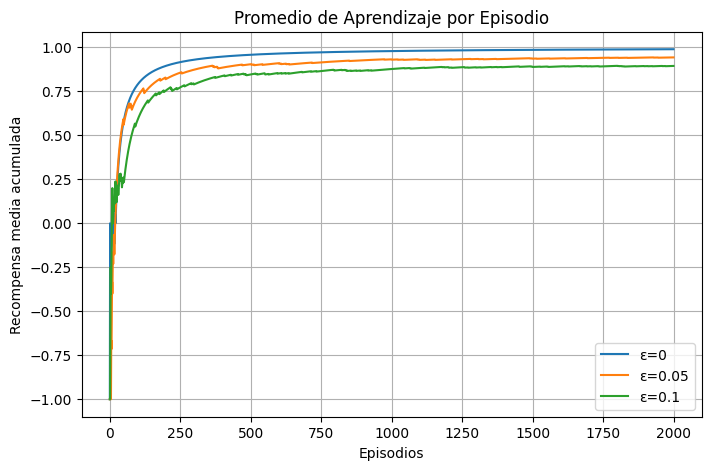

In [26]:
# --- GRÁFICO 2: Promedio acumulado de aprendizaje ---
plt.figure(figsize=(8,5))
for i, eps in enumerate(epsilons):
    promedio_acumulado = np.cumsum(recompensas_medias[i]) / (np.arange(1, episodios+1))
    plt.plot(promedio_acumulado, label=f'ε={eps}')
plt.legend()
plt.xlabel("Episodios")
plt.ylabel("Recompensa media acumulada")
plt.title("Promedio de Aprendizaje por Episodio")
plt.grid(True)
plt.show()

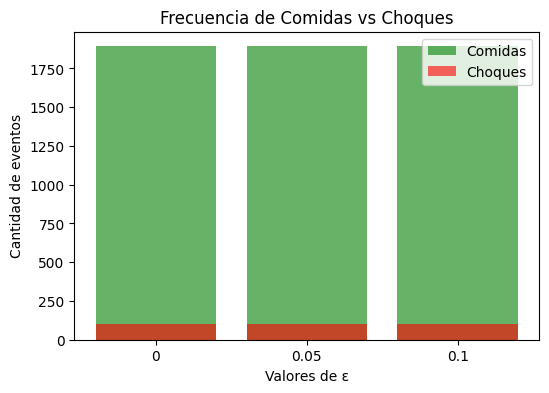

In [27]:
# --- GRÁFICO 3: Comparación visual de comidas vs choques ---
plt.figure(figsize=(6,4))
valores_eps = [str(eps) for eps in epsilons]
plt.bar(valores_eps, [comidas, comidas, comidas], color='green', alpha=0.6, label='Comidas')
plt.bar(valores_eps, [choques, choques, choques], color='red', alpha=0.6, label='Choques')
plt.xlabel("Valores de ε")
plt.ylabel("Cantidad de eventos")
plt.title("Frecuencia de Comidas vs Choques")
plt.legend()
plt.show()